# Result audit
Read-only audit: this notebook reads existing CSV, JSON, and image files only.


In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().parent if Path.cwd().name == "ipy" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import EXPERIMENTS, DATASET_CONFIG, EXPERIMENT_LABELS

_REQUIRED = (
    "table/summary_95.csv",
    "table/summary_by_confidence.csv",
    "table/learner_quality.csv",
    "table/replicate_results.csv",
    "other/diagnostics.csv",
    "other/config_used.json",
)

def locate(exp):
    candidates = []
    for mode in ("full", "fast"):
        base = ROOT / "output" / mode / exp
        if not all((base / rel).exists() for rel in _REQUIRED):
            continue
        config_path = base / "other" / "config_used.json"
        try:
            cfg = json.loads(config_path.read_text(encoding="utf-8"))
        except Exception:
            cfg = {}
        stamp = cfg.get("run_finished_utc") or cfg.get("run_started_utc")
        # ISO UTC timestamps sort lexicographically. Old outputs fall back to mtime.
        rank = (1, stamp, mode == "full") if stamp else (0, config_path.stat().st_mtime_ns, mode == "full")
        candidates.append((rank, mode, base))
    if not candidates:
        return None, None
    _, mode, base = max(candidates, key=lambda item: item[0])
    return mode, base

def show_image(path):
    display(Image(filename=str(path))) if path.exists() else display(Markdown(f"*Missing: `{path}`*"))


## 1. Run scope


In [2]:
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if not base: continue
    cfg=json.loads((base/"other"/"config_used.json").read_text())
    q=pd.read_csv(base/"table"/"learner_quality.csv")
    display(pd.DataFrame([{"experiment":exp,"mode":mode,"replicates":cfg.get("replicates",q.replicate.nunique()),"labelled":cfg.get("labelled_ratio"),"unlabelled":1-cfg.get("labelled_ratio",.1),"PPI train/inference":f"{cfg.get('ppi_train_ratio')}/{1-cfg.get('ppi_train_ratio',.2)}","worker":cfg.get("worker"),"package version":cfg.get("ppi_python_installed")}]))


,experiment,mode,replicates,labelled,unlabelled,PPI train/inference,worker,package version
0,a_mean,full,100,0.1,0.9,0.2/0.8,4,0.2.3


,experiment,mode,replicates,labelled,unlabelled,PPI train/inference,worker,package version
0,b_lr,full,100,0.1,0.9,0.2/0.8,4,0.2.3


,experiment,mode,replicates,labelled,unlabelled,PPI train/inference,worker,package version
0,c_glm,full,100,0.1,0.9,0.2/0.8,4,0.2.3


## 2. Experiment formulation
Mean, linear-regression, and logistic-GLM targets are defined in the README; empirical truth and formulas are not recomputed here.


## 3. Learner training protocol
Candidates are selected by validation Brier score/MSE and refit on all `PPI_train`; preprocessing, grids, and final sample sizes are recorded in the training summary and configuration.


## 4. Learner prediction quality


### Galaxy Zoo 2 mean estimation

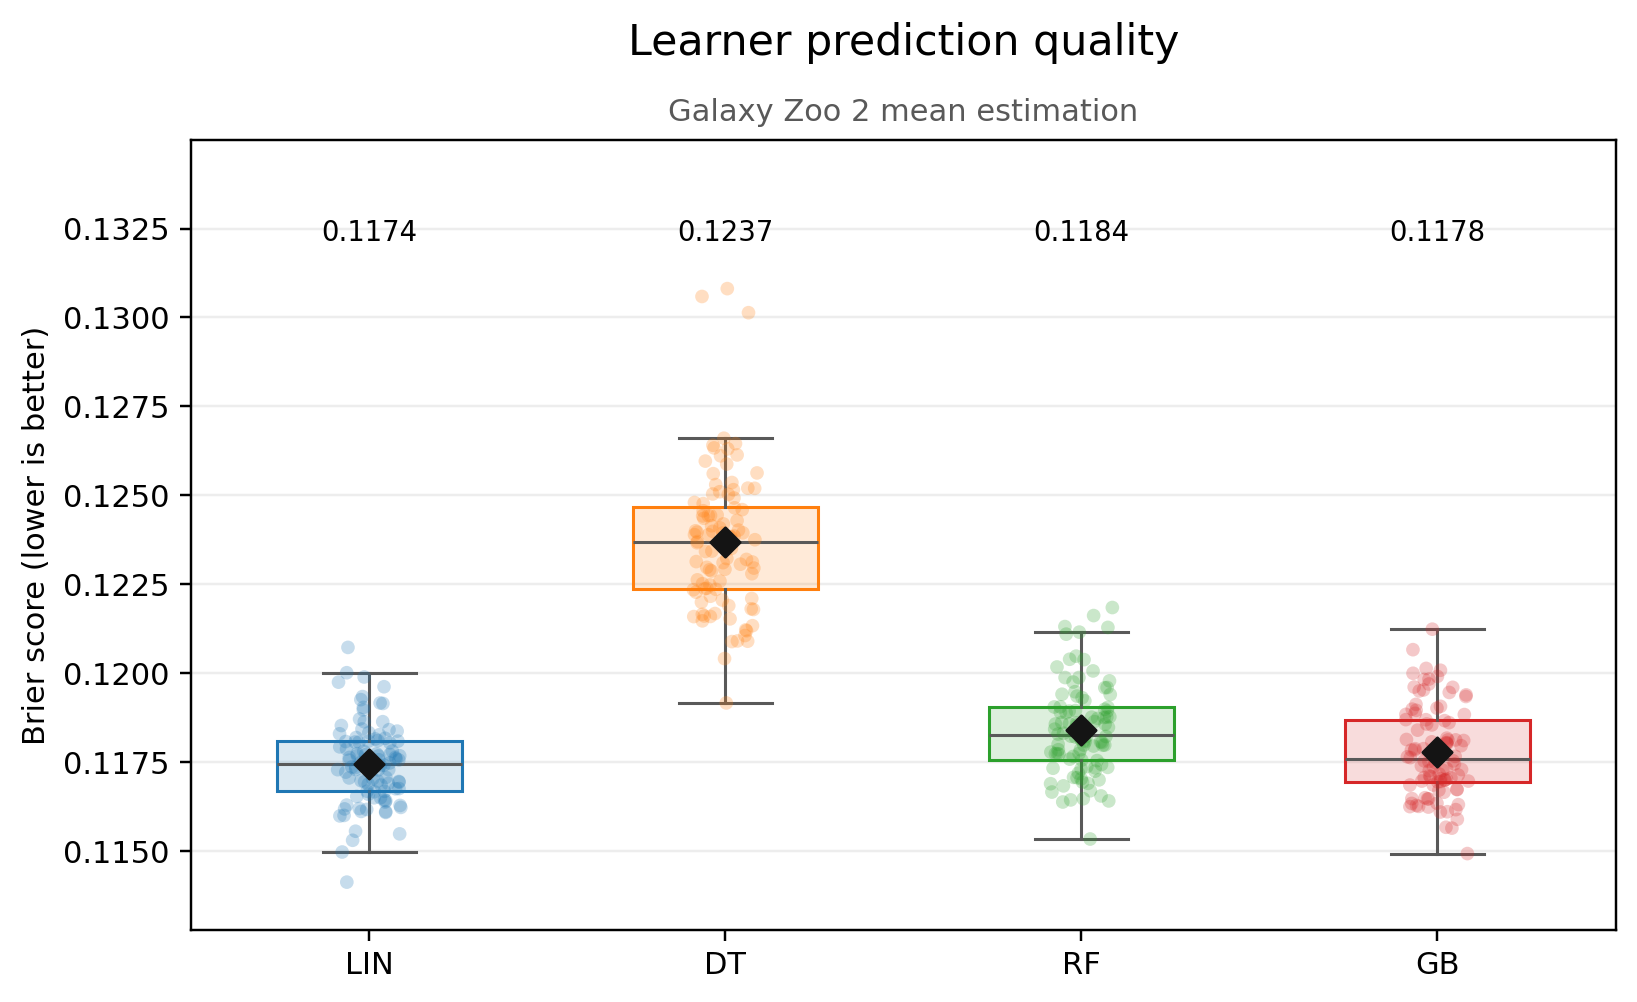

,learner_label,quality_metric,quality_mean,quality_sd
0,DT,Brier,0.123693,0.001975
1,GB,Brier,0.117781,0.001262
2,LIN,Brier,0.117448,0.001133
3,RF,Brier,0.118400,0.001270


### ACS PUMS linear regression

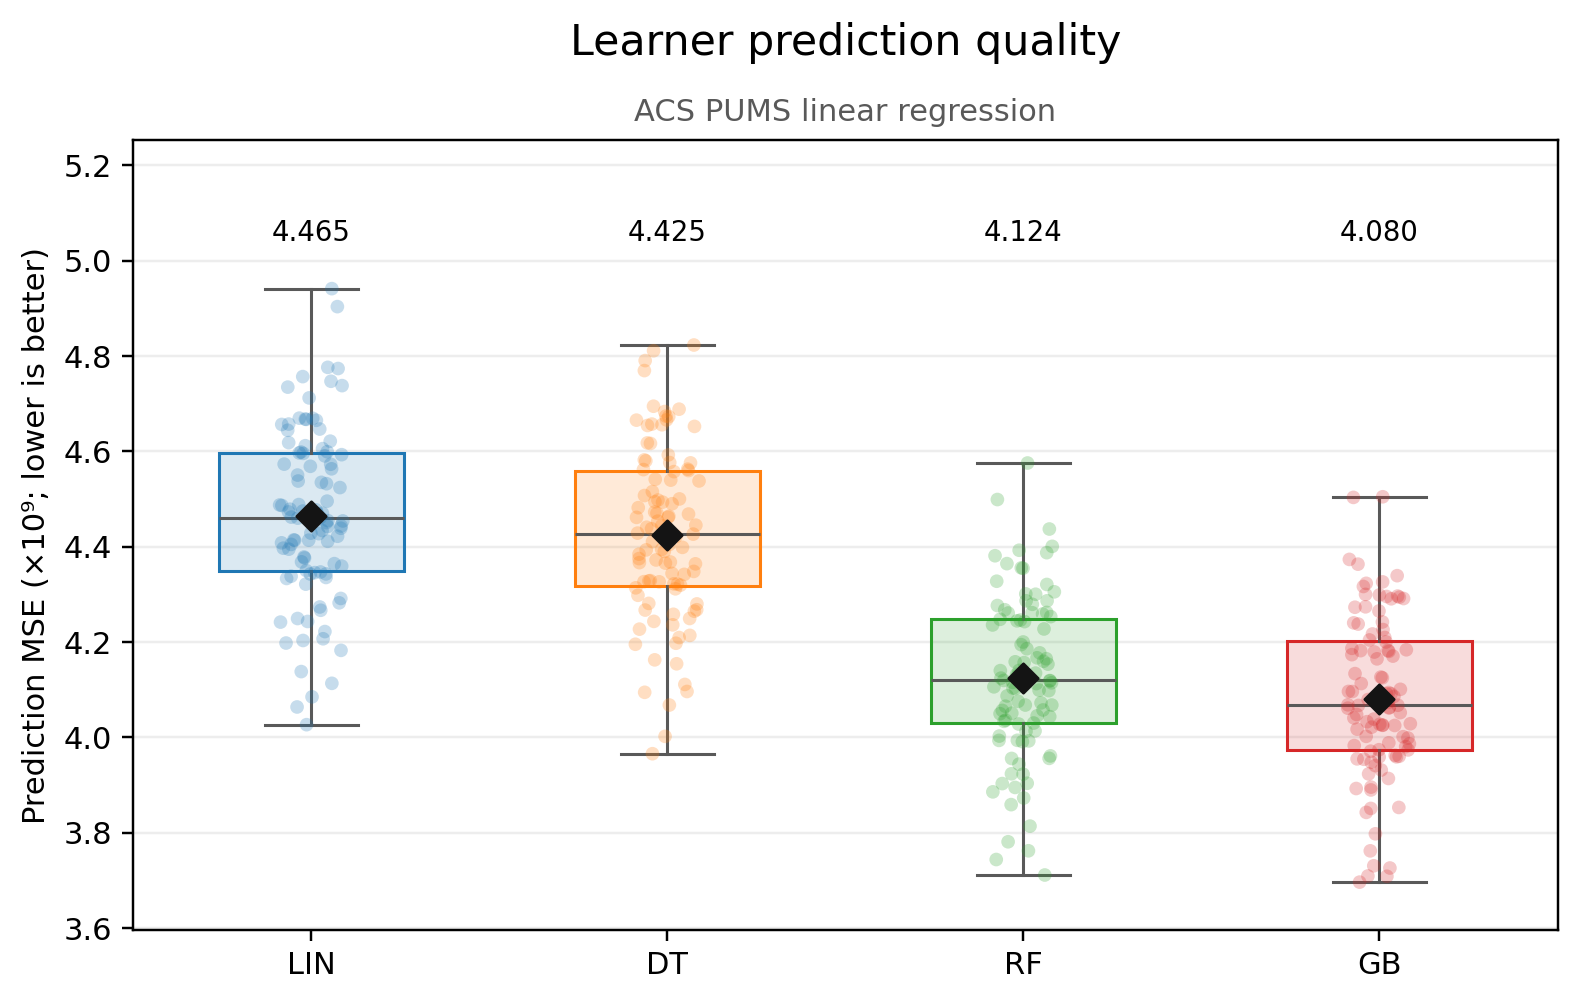

,learner_label,quality_metric,quality_mean,quality_sd
0,DT,MSE,4.425144e+09,1.797079e+08
1,GB,MSE,4.079748e+09,1.711889e+08
2,LIN,MSE,4.464909e+09,1.791265e+08
3,RF,MSE,4.124454e+09,1.675302e+08


### Adult logistic GLM

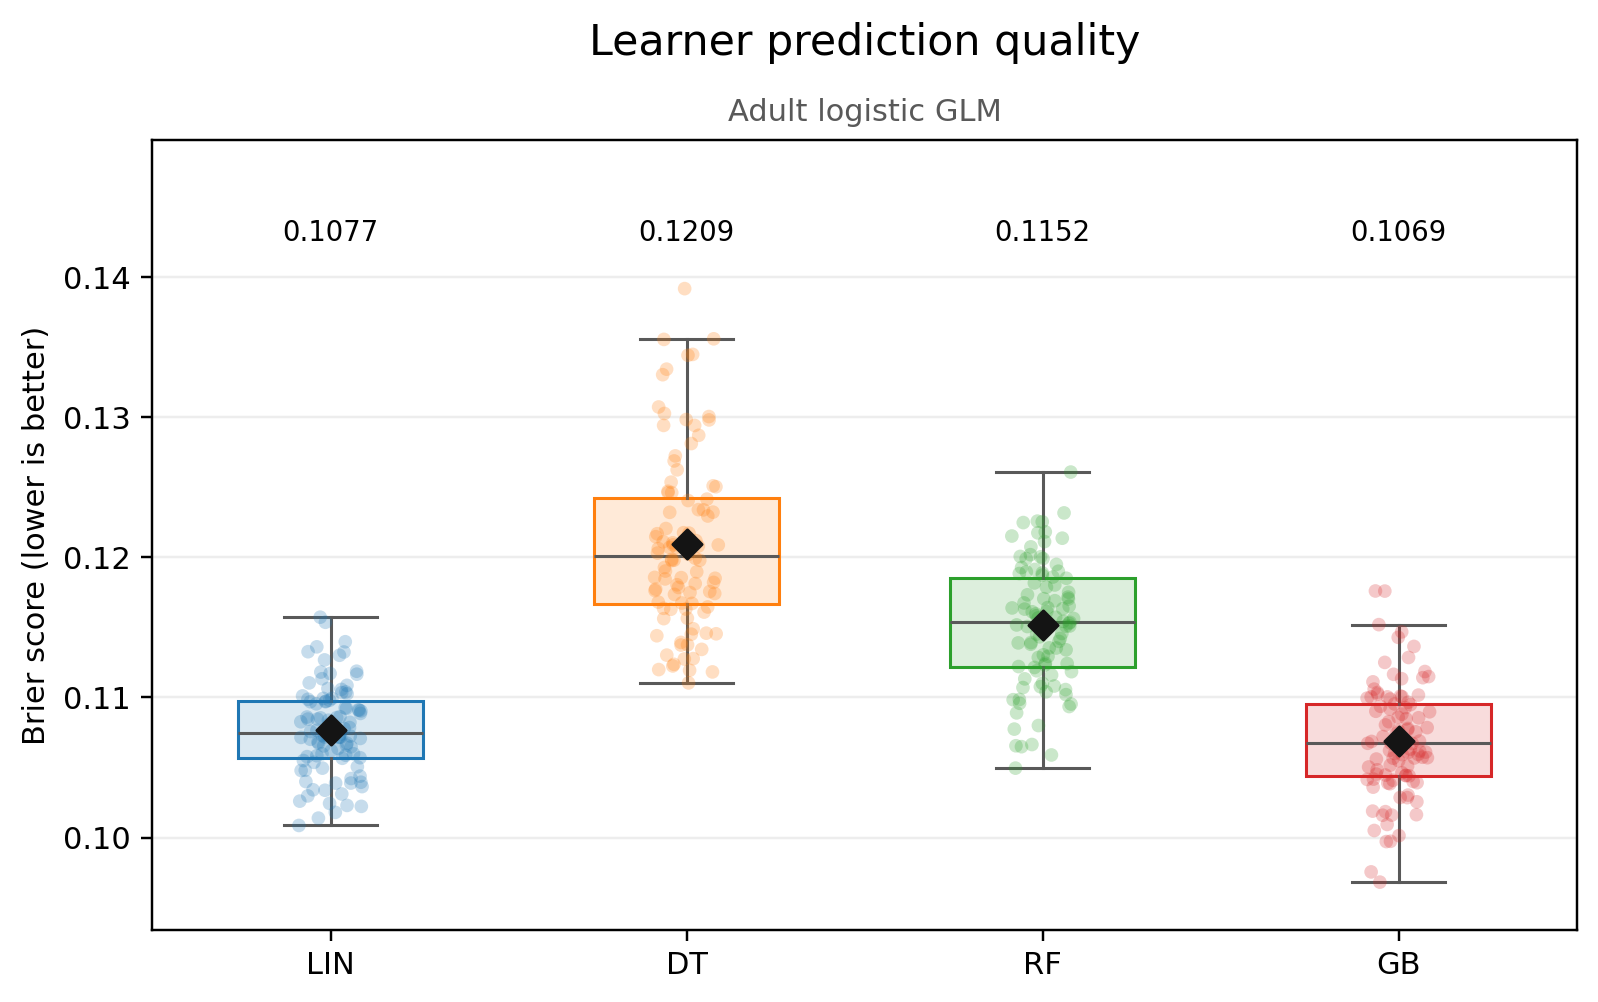

,learner_label,quality_metric,quality_mean,quality_sd
0,DT,Brier,0.120939,0.006206
1,GB,Brier,0.106913,0.003982
2,LIN,Brier,0.107662,0.003176
3,RF,Brier,0.115170,0.004358


In [3]:
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if not base: continue
    display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); show_image(base/"figure"/"learner_quality.png")
    q=pd.read_csv(base/"table"/"learner_quality.csv")
    display(q.groupby(["learner_label","quality_metric"],as_index=False).quality_value.agg(quality_mean="mean",quality_sd="std"))


## 5. 95% inference performance
Coverage error assesses validity relative to 95% nominal coverage. Relative width assesses efficiency relative to full-labelled Classic. Hollow efficiency markers indicate coverage outside the nominal Monte Carlo band.


### Galaxy Zoo 2 mean estimation

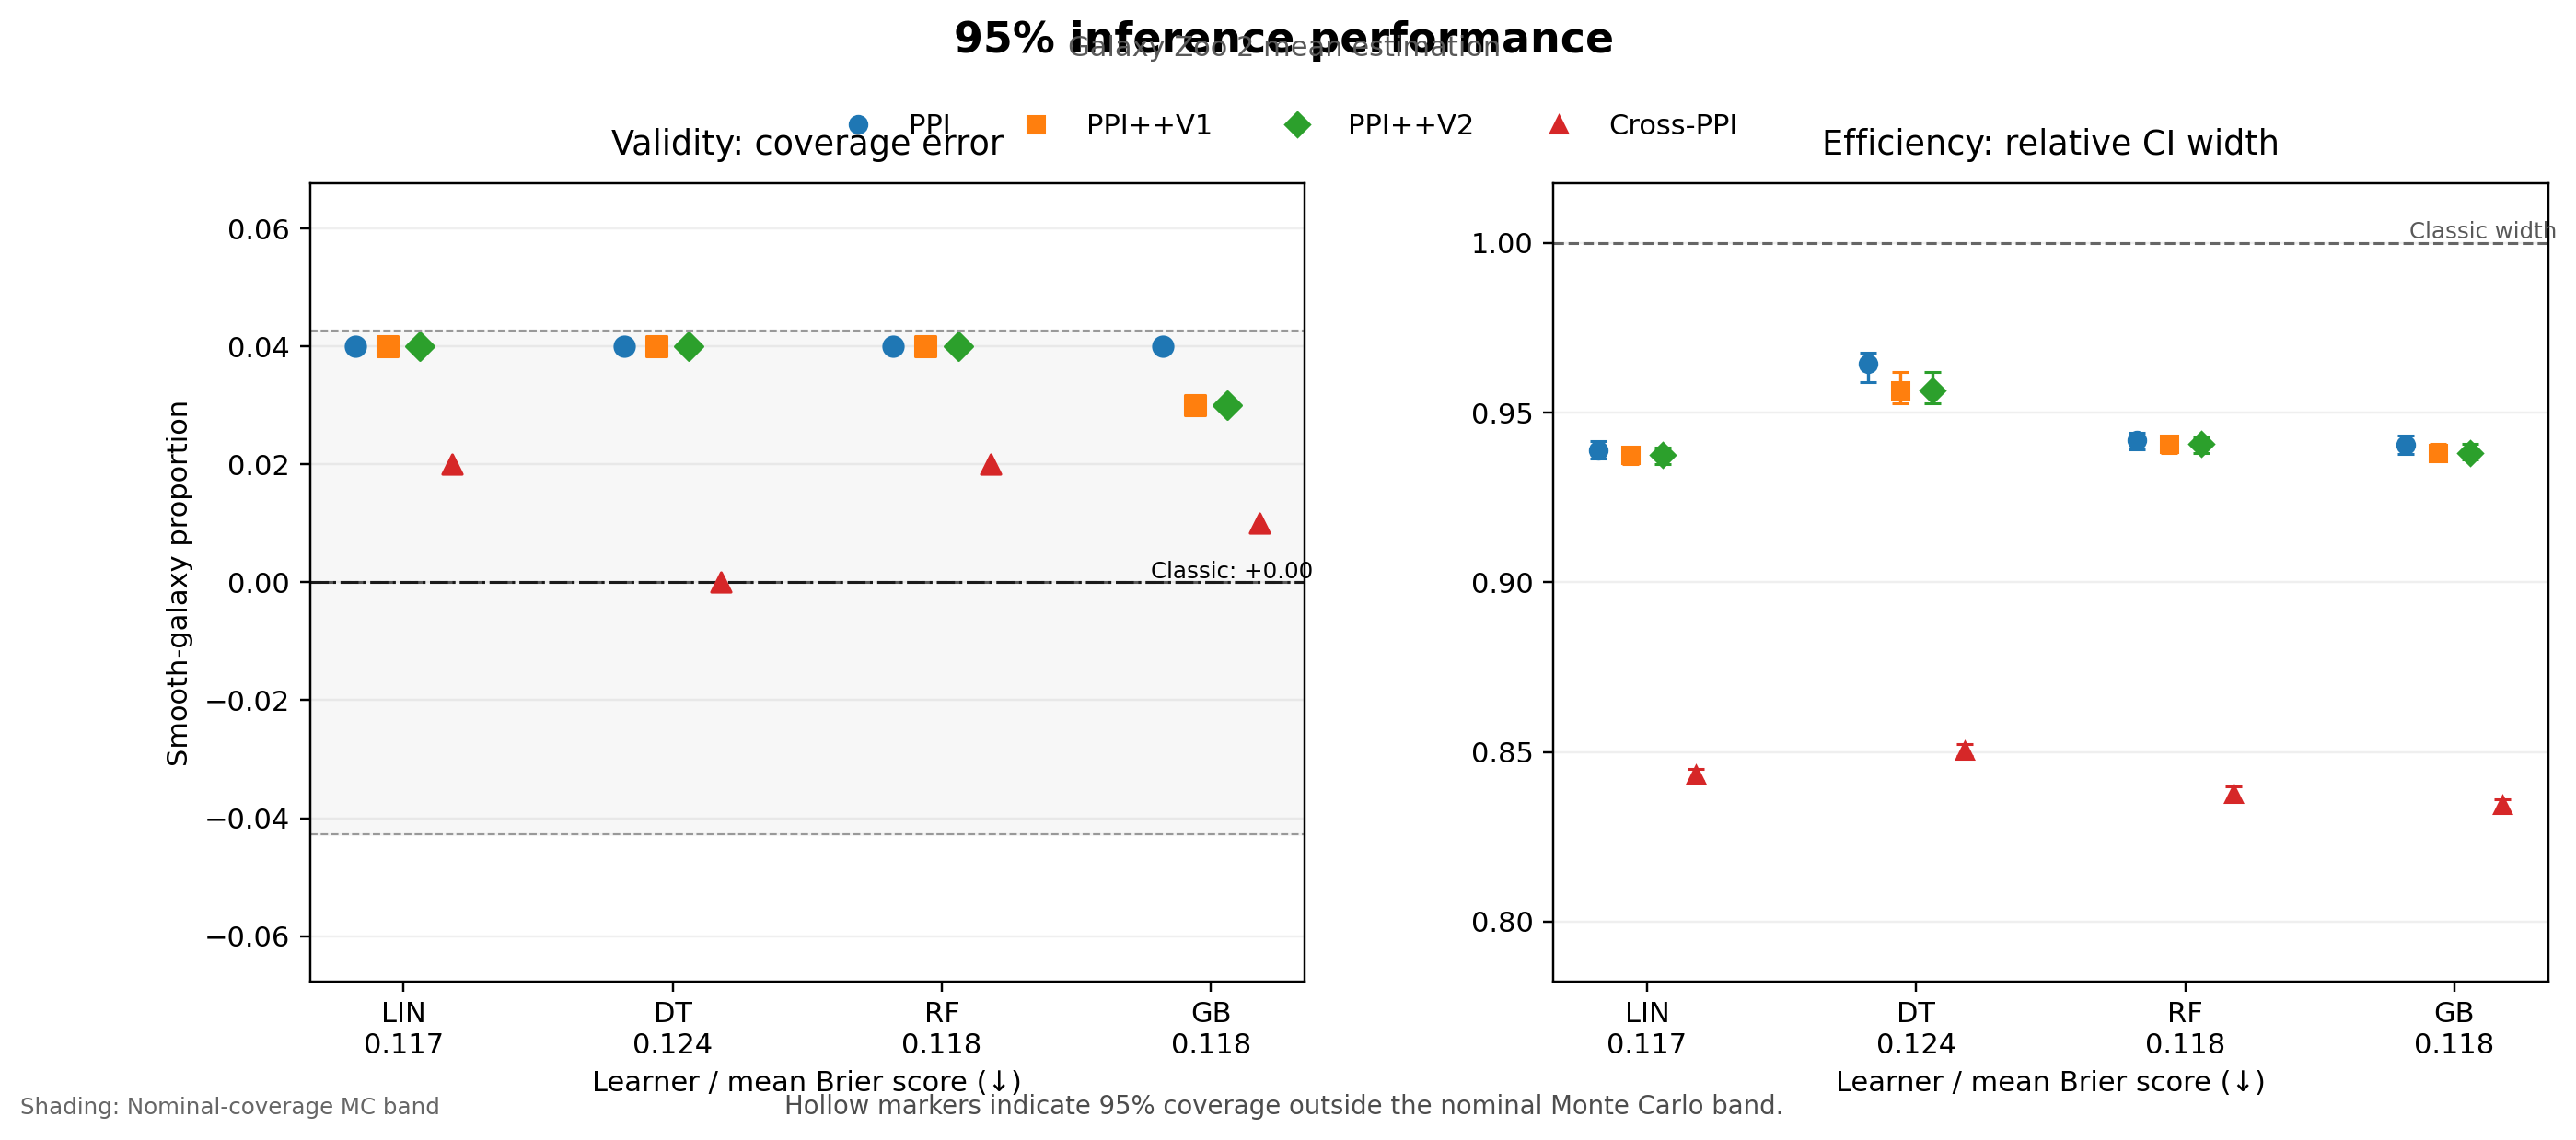

### ACS PUMS linear regression

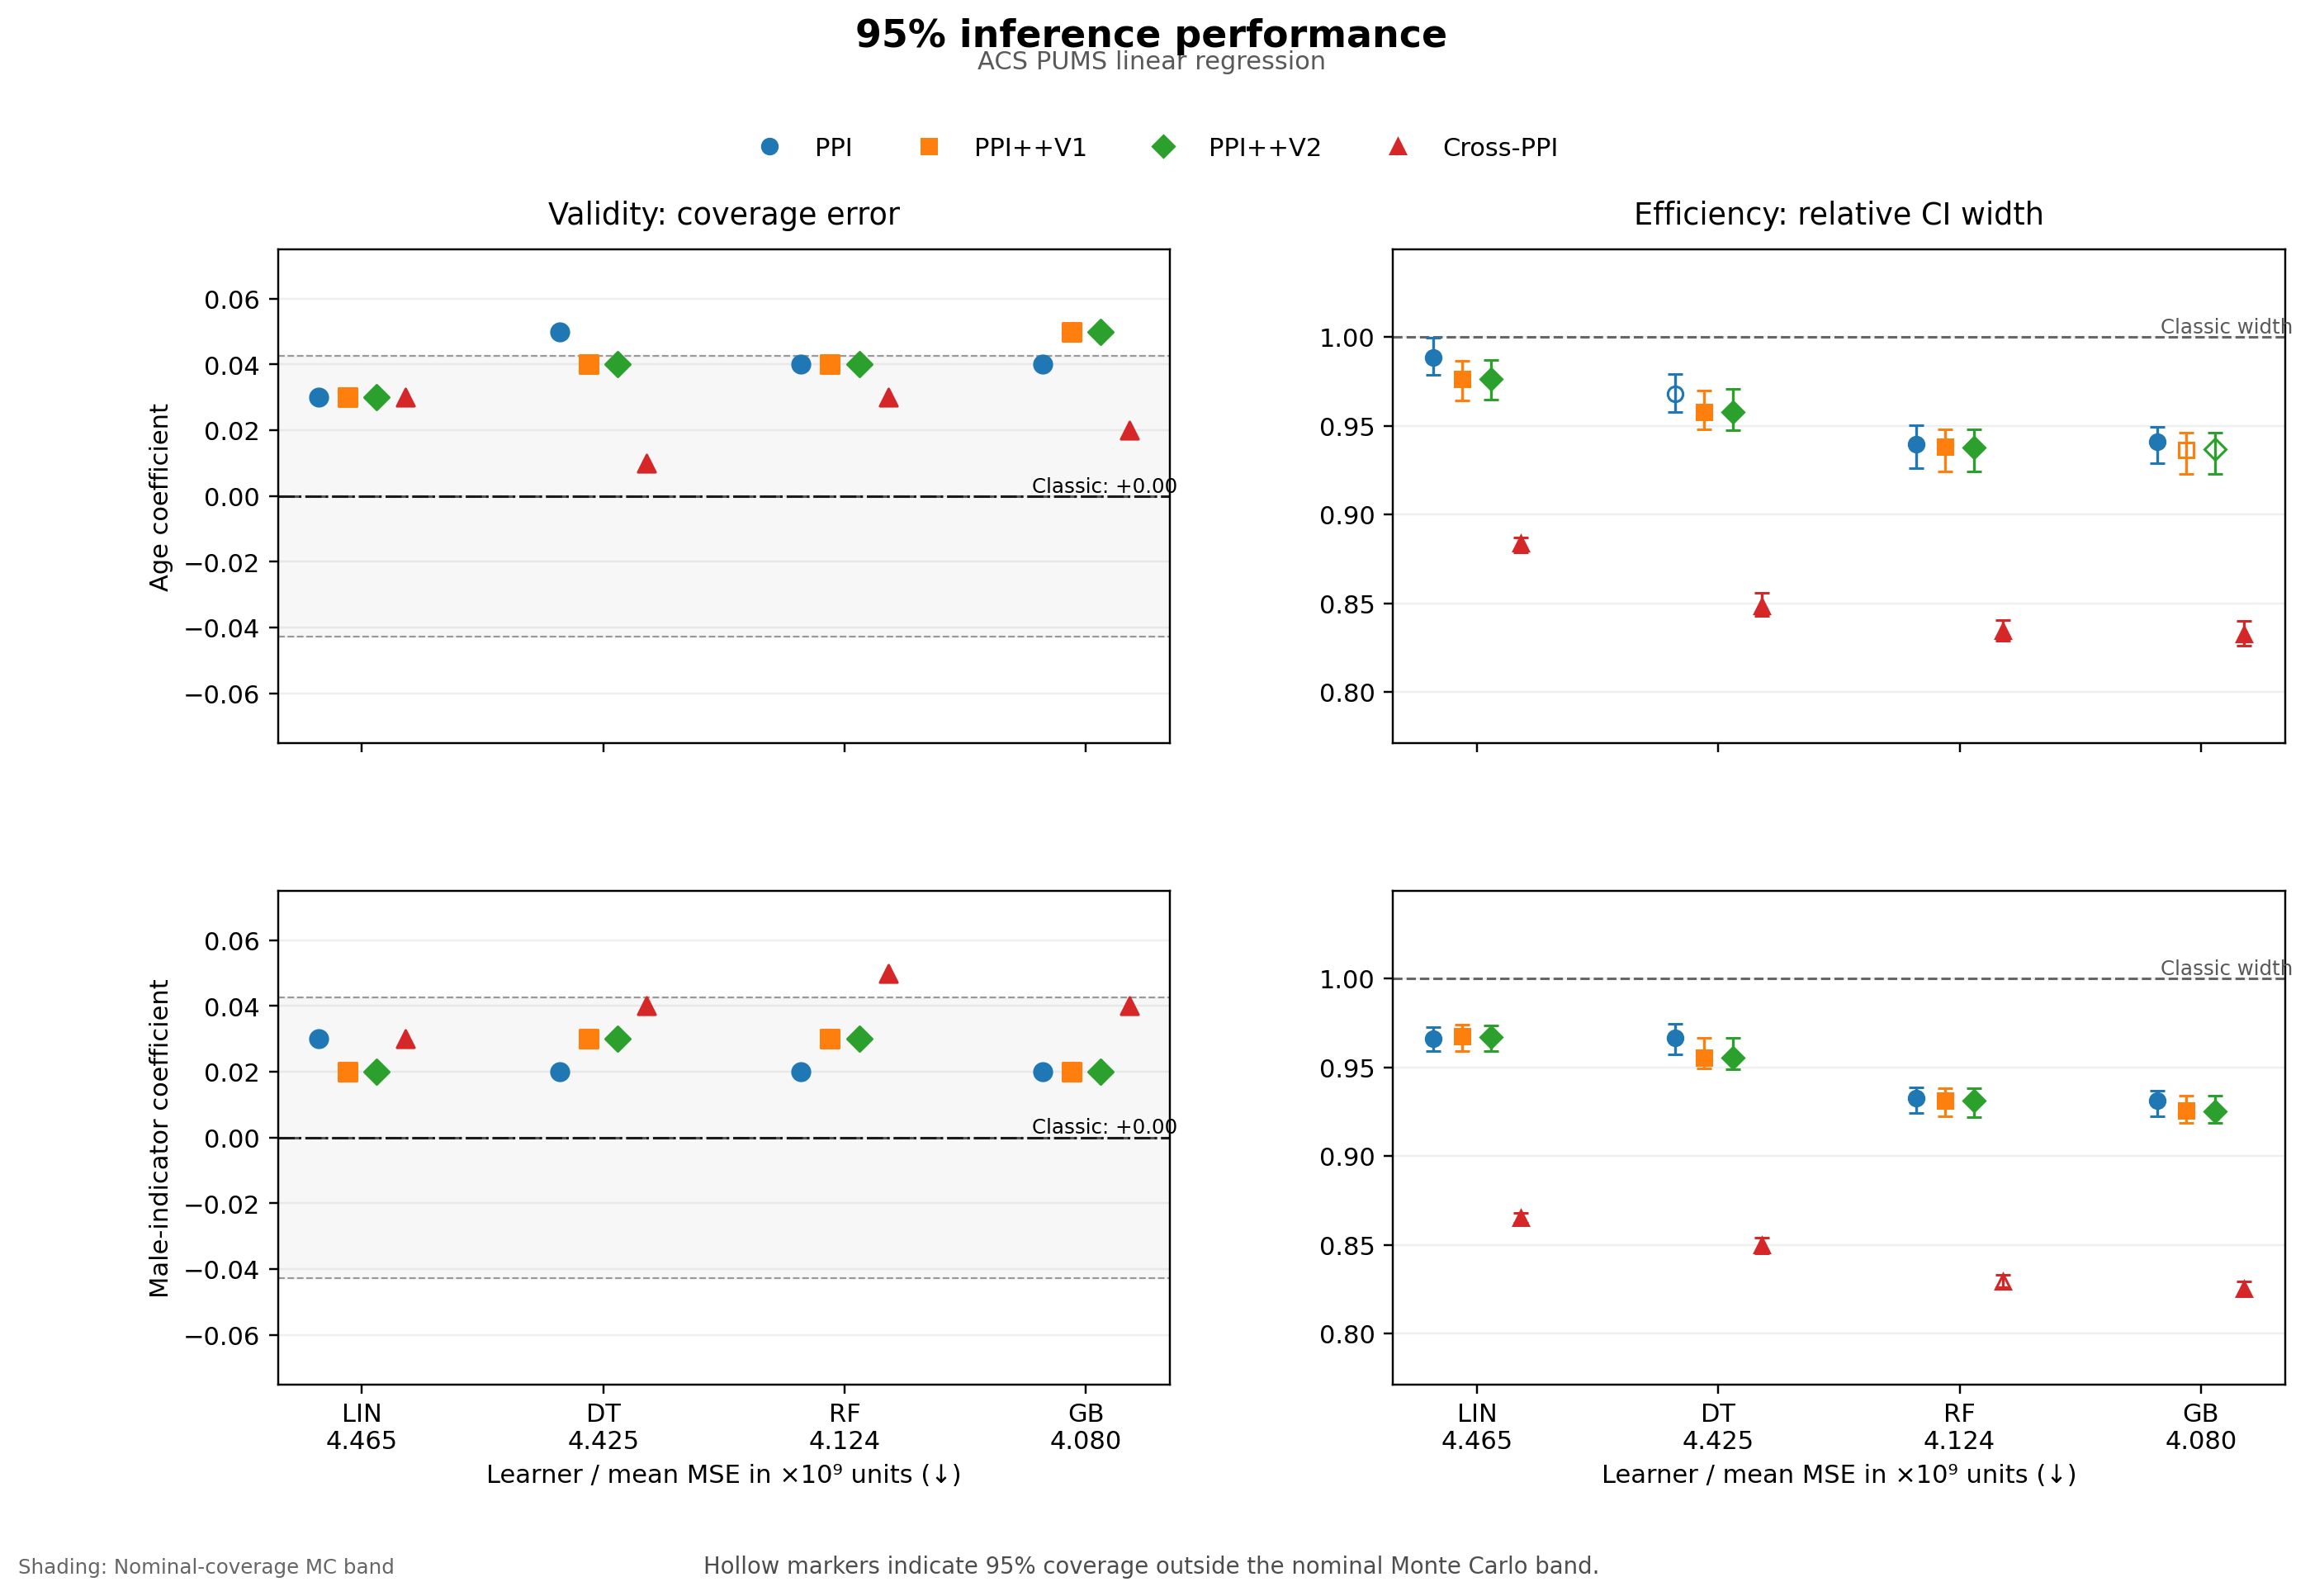

### Adult logistic GLM

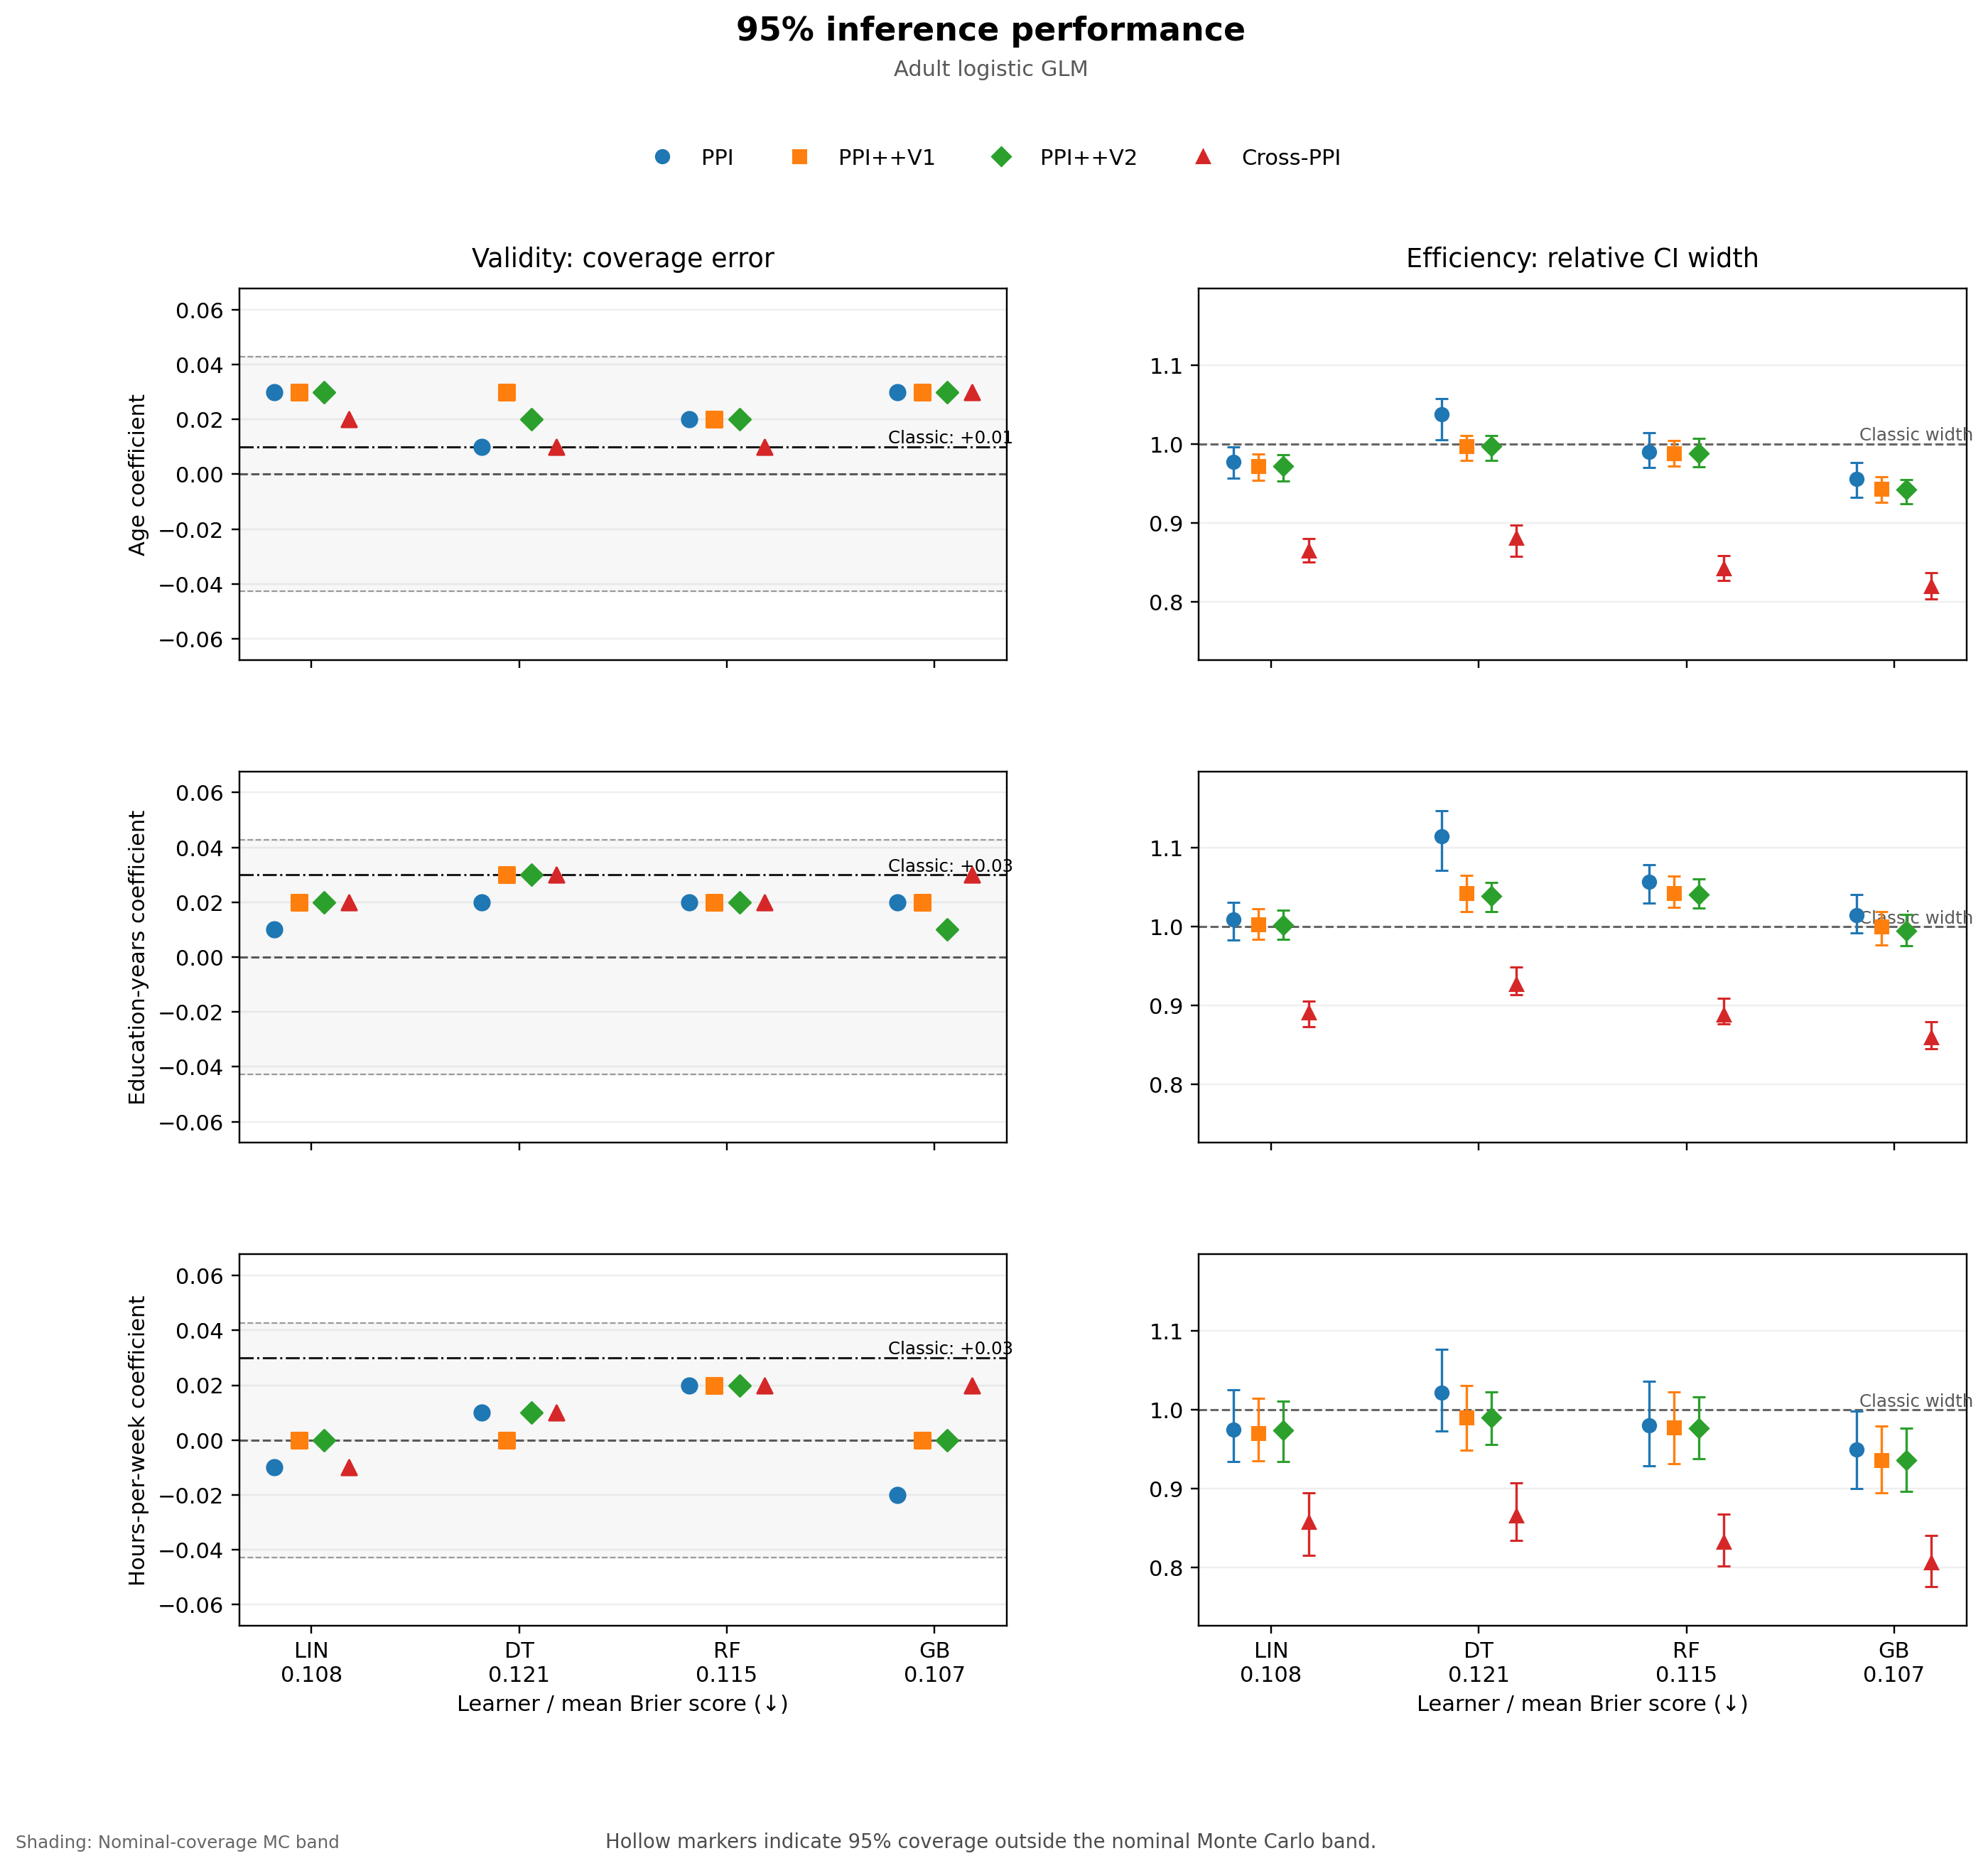

In [4]:
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base: display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); show_image(base/"figure"/"inference_performance_95.png")


## 6. Numerical 95% result table


In [5]:
cols=["parameter","learner_label","method_label","coverage","coverage_error","avg_width","relative_width_rep_median","relative_width_rep_q25","relative_width_rep_q75","quality_value_mean","median_lambda","n_failed"]
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base:
        x=pd.read_csv(base/"table"/"summary_95.csv"); display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); display(x[[z for z in cols if z in x]])


### Galaxy Zoo 2 mean estimation

,parameter,learner_label,method_label,coverage,coverage_error,avg_width,relative_width_rep_median,relative_width_rep_q25,relative_width_rep_q75,quality_value_mean,median_lambda,n_failed
0,smooth_proportion,DT,Cross-PPI,0.95,0.00,0.008971,0.850343,0.848781,0.852420,0.123693,NaN,0
1,smooth_proportion,DT,Naive ML,0.17,-0.78,0.002083,0.198713,0.194267,0.202862,0.123693,NaN,0
2,smooth_proportion,DT,PPI,0.99,0.04,0.010171,0.964472,0.958883,0.967586,0.123693,NaN,0
3,smooth_proportion,DT,PPI++V1,0.99,0.04,0.010096,0.956584,0.952634,0.961940,0.123693,NaN,0
4,smooth_proportion,DT,PPI++V2,0.99,0.04,0.010096,0.956611,0.952662,0.961970,0.123693,0.825,0
5,smooth_proportion,GB,Cross-PPI,0.96,0.01,0.008800,0.834371,0.832308,0.836080,0.117781,NaN,0
6,smooth_proportion,GB,Naive ML,0.21,-0.74,0.002008,0.190663,0.187729,0.192828,0.117781,NaN,0
7,smooth_proportion,GB,PPI,0.99,0.04,0.009920,0.940487,0.937704,0.943166,0.117781,NaN,0
8,smooth_proportion,GB,PPI++V1,0.98,0.03,0.009899,0.938161,0.936030,0.940846,0.117781,NaN,0
9,smooth_proportion,GB,PPI++V2,0.98,0.03,0.009899,0.938182,0.936054,0.940863,0.117781,0.900,0


### ACS PUMS linear regression

,parameter,learner_label,method_label,coverage,coverage_error,avg_width,relative_width_rep_median,relative_width_rep_q25,relative_width_rep_q75,quality_value_mean,median_lambda,n_failed
0,AGEP,DT,Cross-PPI,0.96,0.01,62.791058,0.848401,0.842812,0.856026,4.425144e+09,NaN,0
1,AGEP,DT,Naive ML,0.09,-0.86,14.680201,0.196710,0.191319,0.205592,4.425144e+09,NaN,0
2,AGEP,DT,PPI,1.00,0.05,71.462374,0.968084,0.957734,0.979064,4.425144e+09,NaN,0
3,AGEP,DT,PPI++V1,0.99,0.04,70.772821,0.957608,0.947898,0.969871,4.425144e+09,NaN,0
4,AGEP,DT,PPI++V2,0.99,0.04,70.783129,0.957903,0.947543,0.970634,4.425144e+09,0.8000,0
5,AGEP,GB,Cross-PPI,0.97,0.02,61.578732,0.832837,0.826277,0.840282,4.079748e+09,NaN,0
6,AGEP,GB,Naive ML,0.15,-0.80,14.790592,0.198560,0.193102,0.209196,4.079748e+09,NaN,0
7,AGEP,GB,PPI,0.99,0.04,69.415624,0.941192,0.928900,0.949416,4.079748e+09,NaN,0
8,AGEP,GB,PPI++V1,1.00,0.05,69.036625,0.936467,0.922688,0.946112,4.079748e+09,NaN,0
9,AGEP,GB,PPI++V2,1.00,0.05,69.037868,0.936651,0.923022,0.946122,4.079748e+09,0.8750,0


### Adult logistic GLM

,parameter,learner_label,method_label,coverage,coverage_error,avg_width,relative_width_rep_median,relative_width_rep_q25,relative_width_rep_q75,quality_value_mean,median_lambda,n_failed
0,age,DT,Cross-PPI,0.96,0.01,0.009443,0.880773,0.857661,0.897085,0.120939,NaN,0
1,age,DT,Naive ML,0.07,-0.88,0.002085,0.190915,0.179535,0.210688,0.120939,NaN,0
2,age,DT,PPI,0.96,0.01,0.011134,1.037180,1.004870,1.057511,0.120939,NaN,0
3,age,DT,PPI++V1,0.98,0.03,0.010719,0.997170,0.978983,1.010246,0.120939,NaN,0
4,age,DT,PPI++V2,0.97,0.02,0.010723,0.997310,0.979428,1.010982,0.120939,0.550,0
...,...,...,...,...,...,...,...,...,...,...,...,...
58,hours-per-week,RF,Cross-PPI,0.97,0.02,0.011296,0.832472,0.802237,0.867829,0.115170,NaN,0
59,hours-per-week,RF,Naive ML,0.00,-0.95,0.001964,0.145388,0.137523,0.153172,0.115170,NaN,0
60,hours-per-week,RF,PPI,0.97,0.02,0.013303,0.980540,0.928572,1.036278,0.115170,NaN,0
61,hours-per-week,RF,PPI++V1,0.97,0.02,0.013219,0.977546,0.931287,1.022747,0.115170,NaN,0


## 7. Calibration diagnostics
Markers are horizontally offset within each nominal confidence level so that coincident PPI, PPI++V1, and PPI++V2 results remain visible.


### Galaxy Zoo 2 mean estimation — smooth_proportion

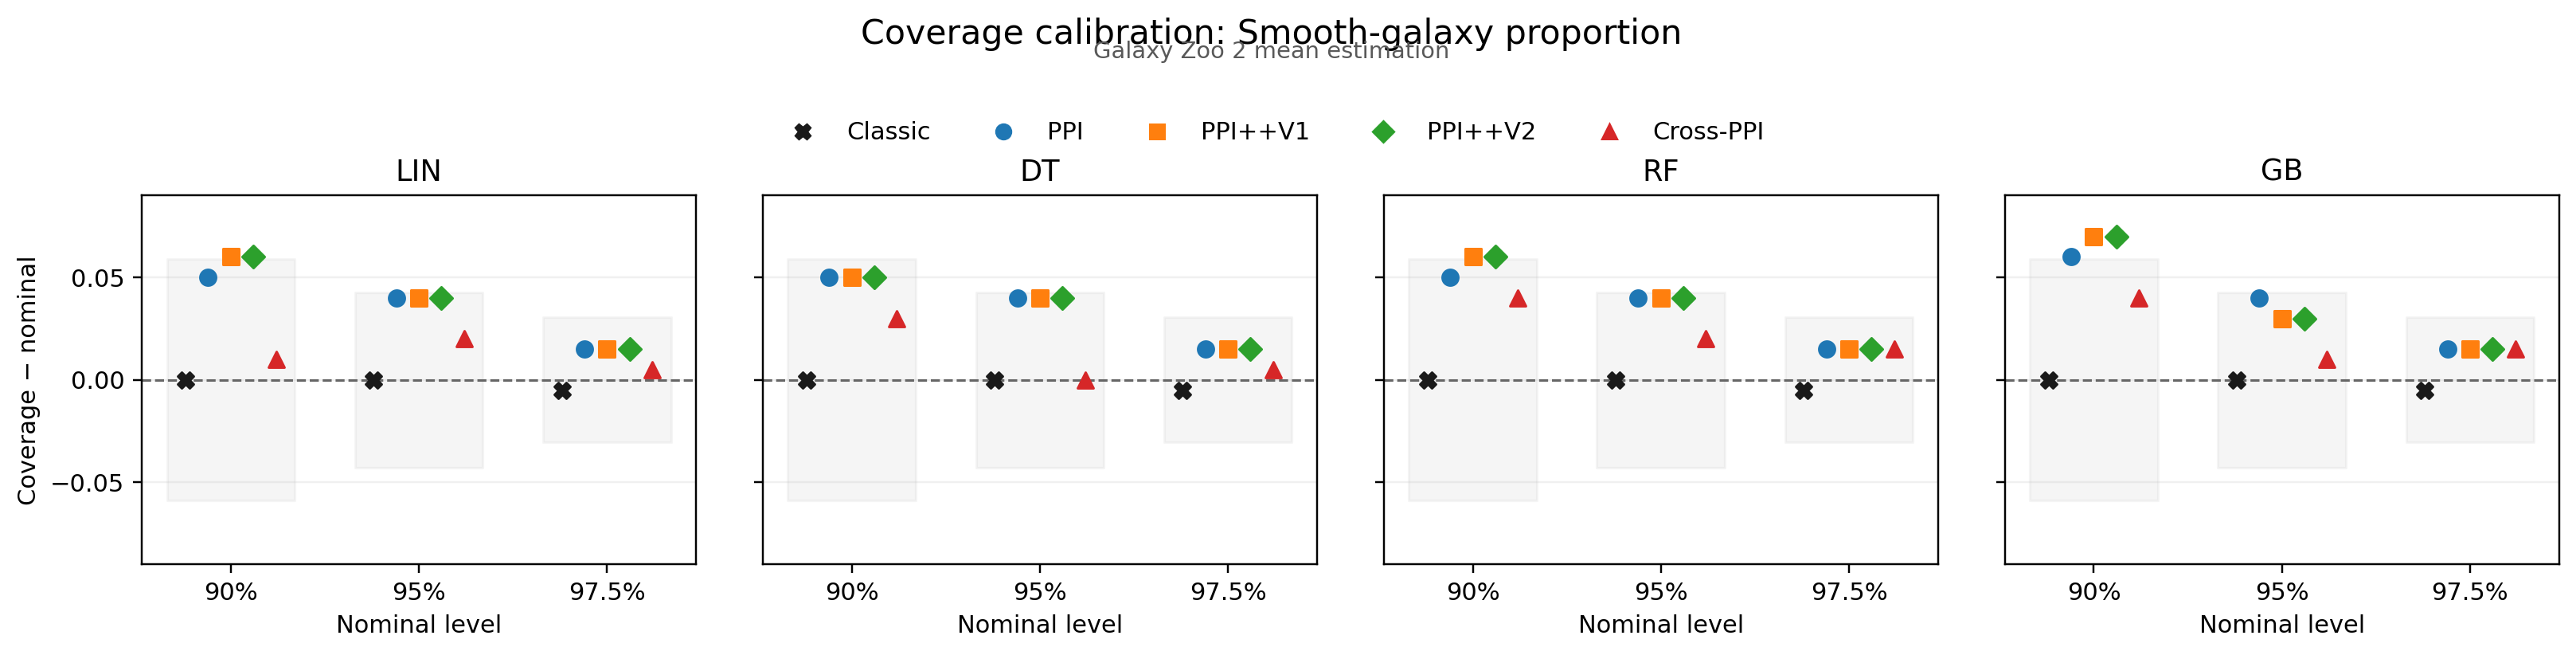

### ACS PUMS linear regression — AGEP

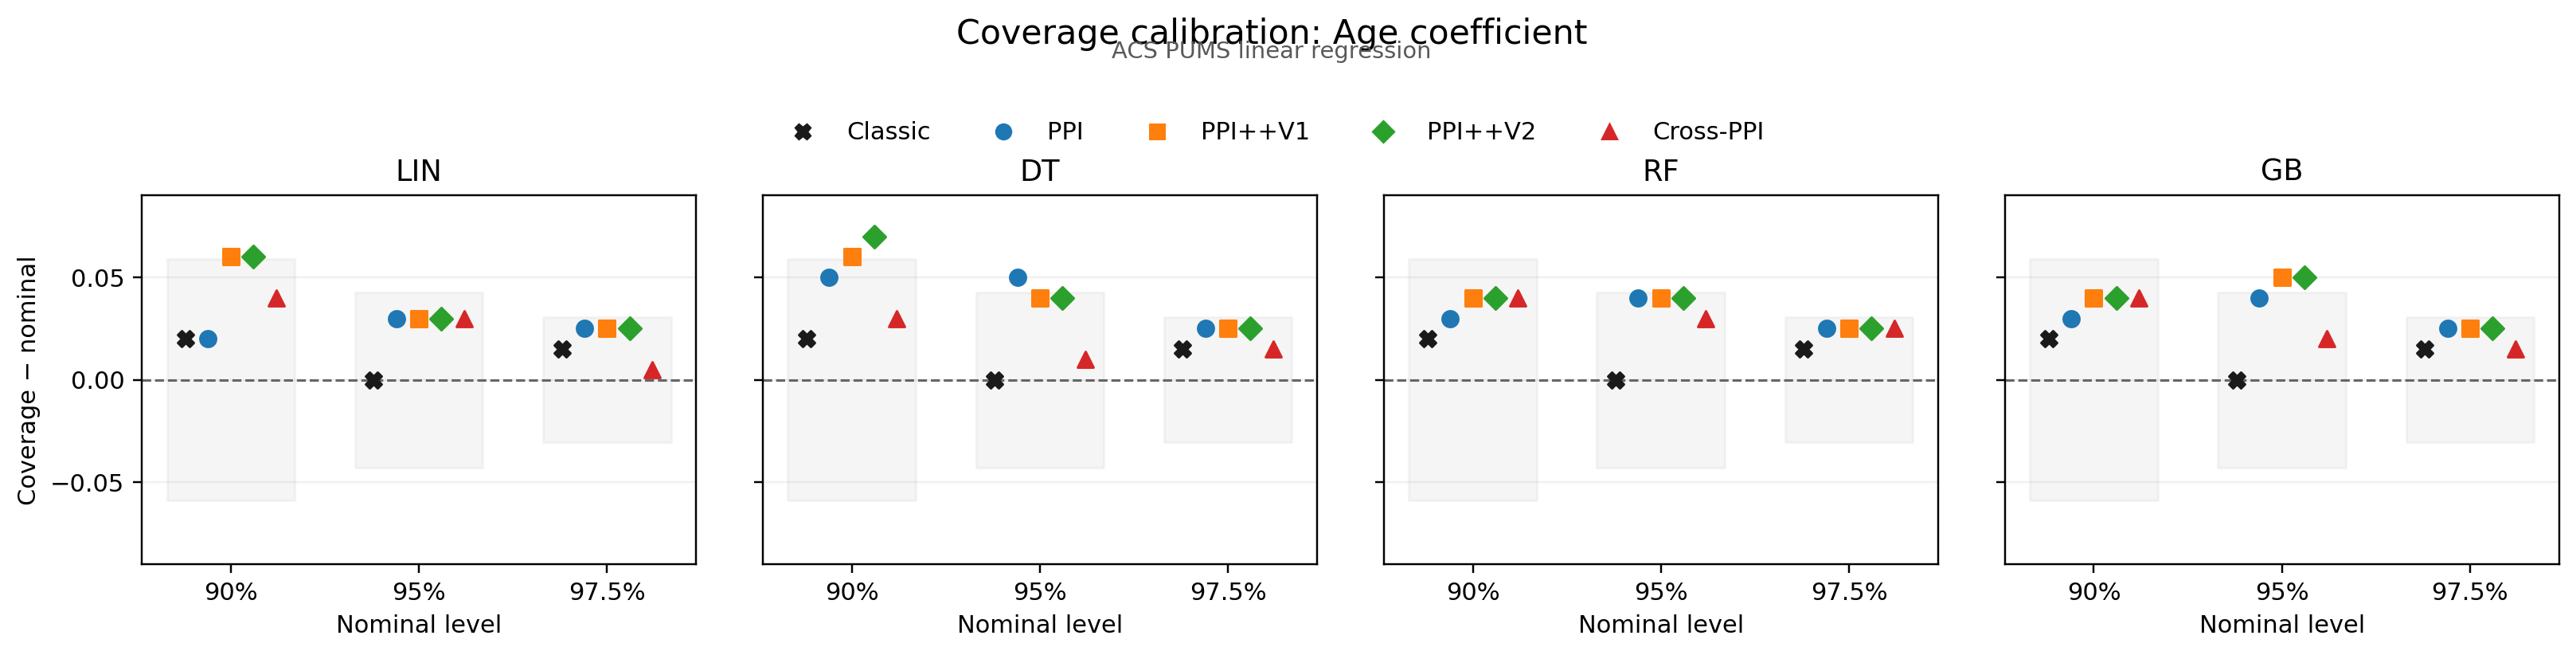

### ACS PUMS linear regression — SEX_MALE

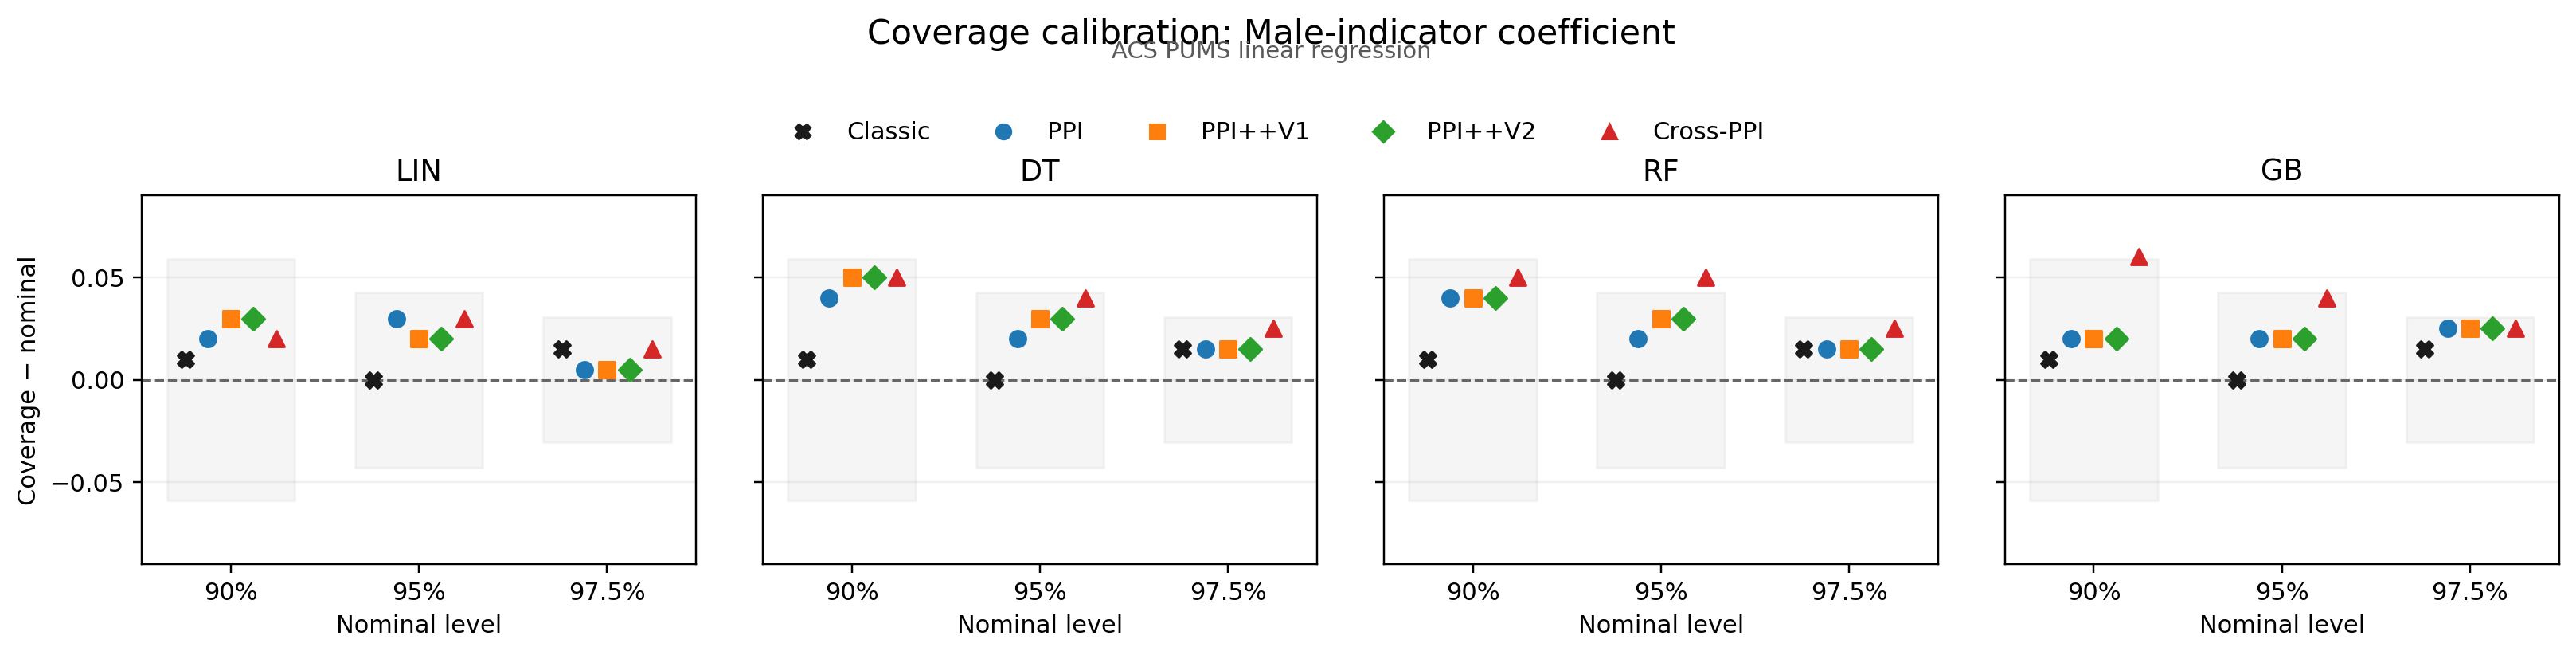

### Adult logistic GLM — age

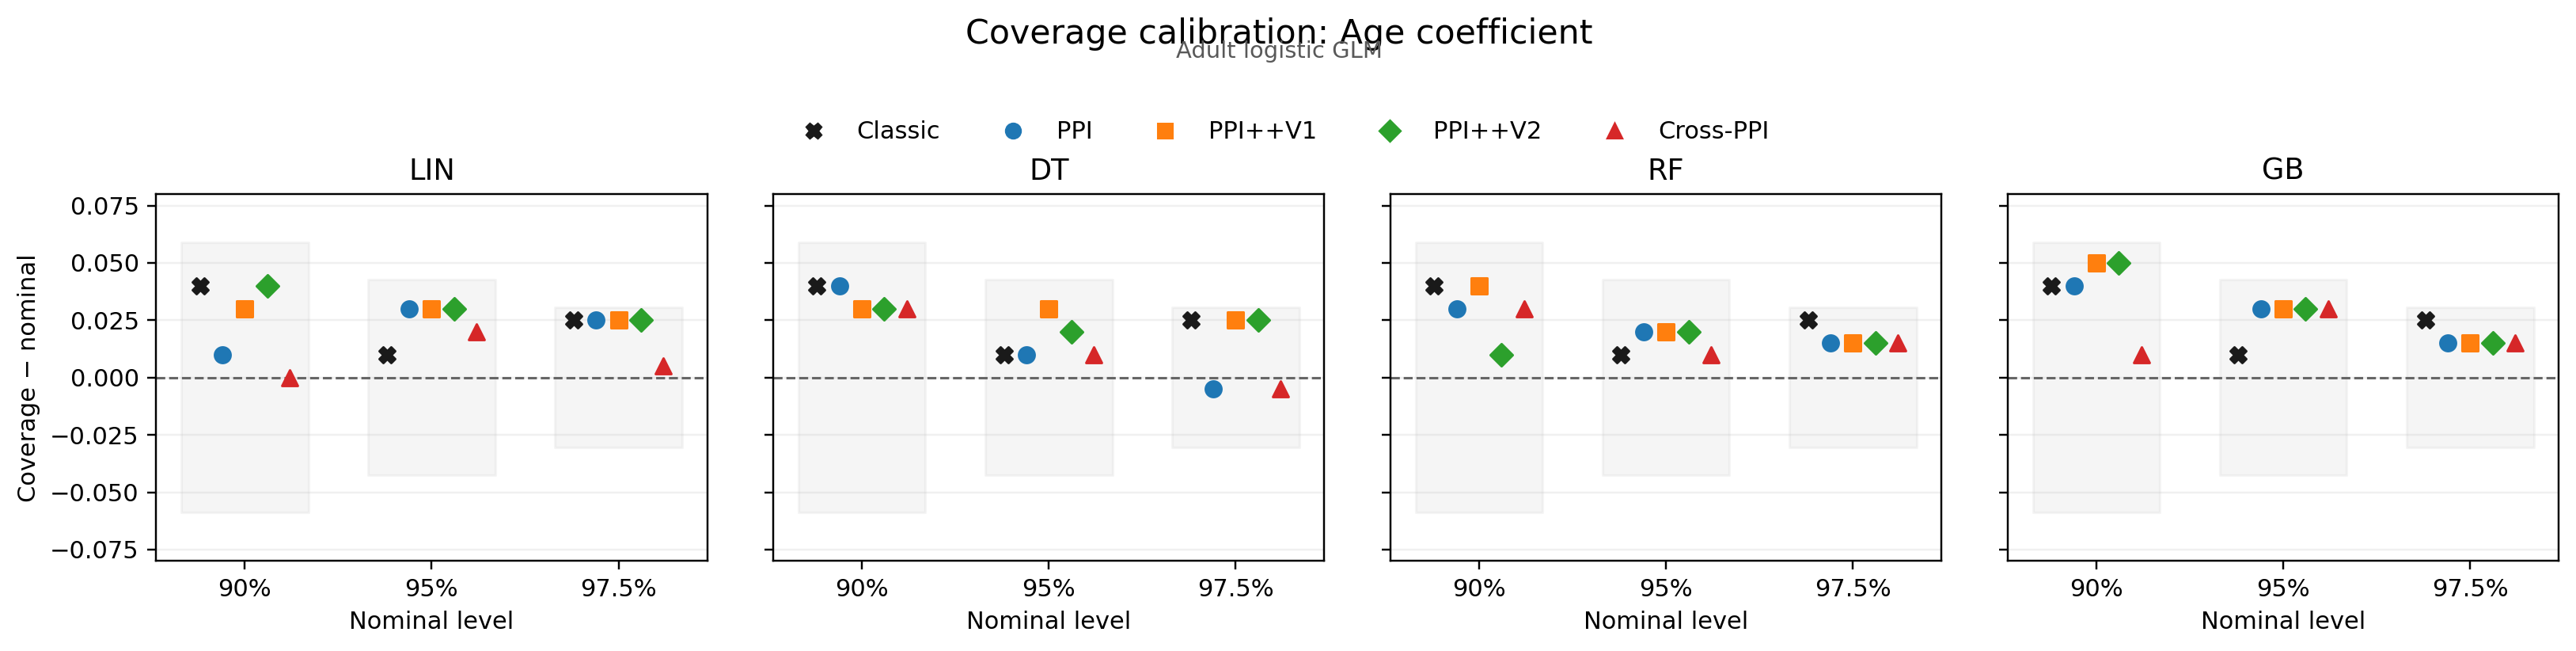

### Adult logistic GLM — education-num

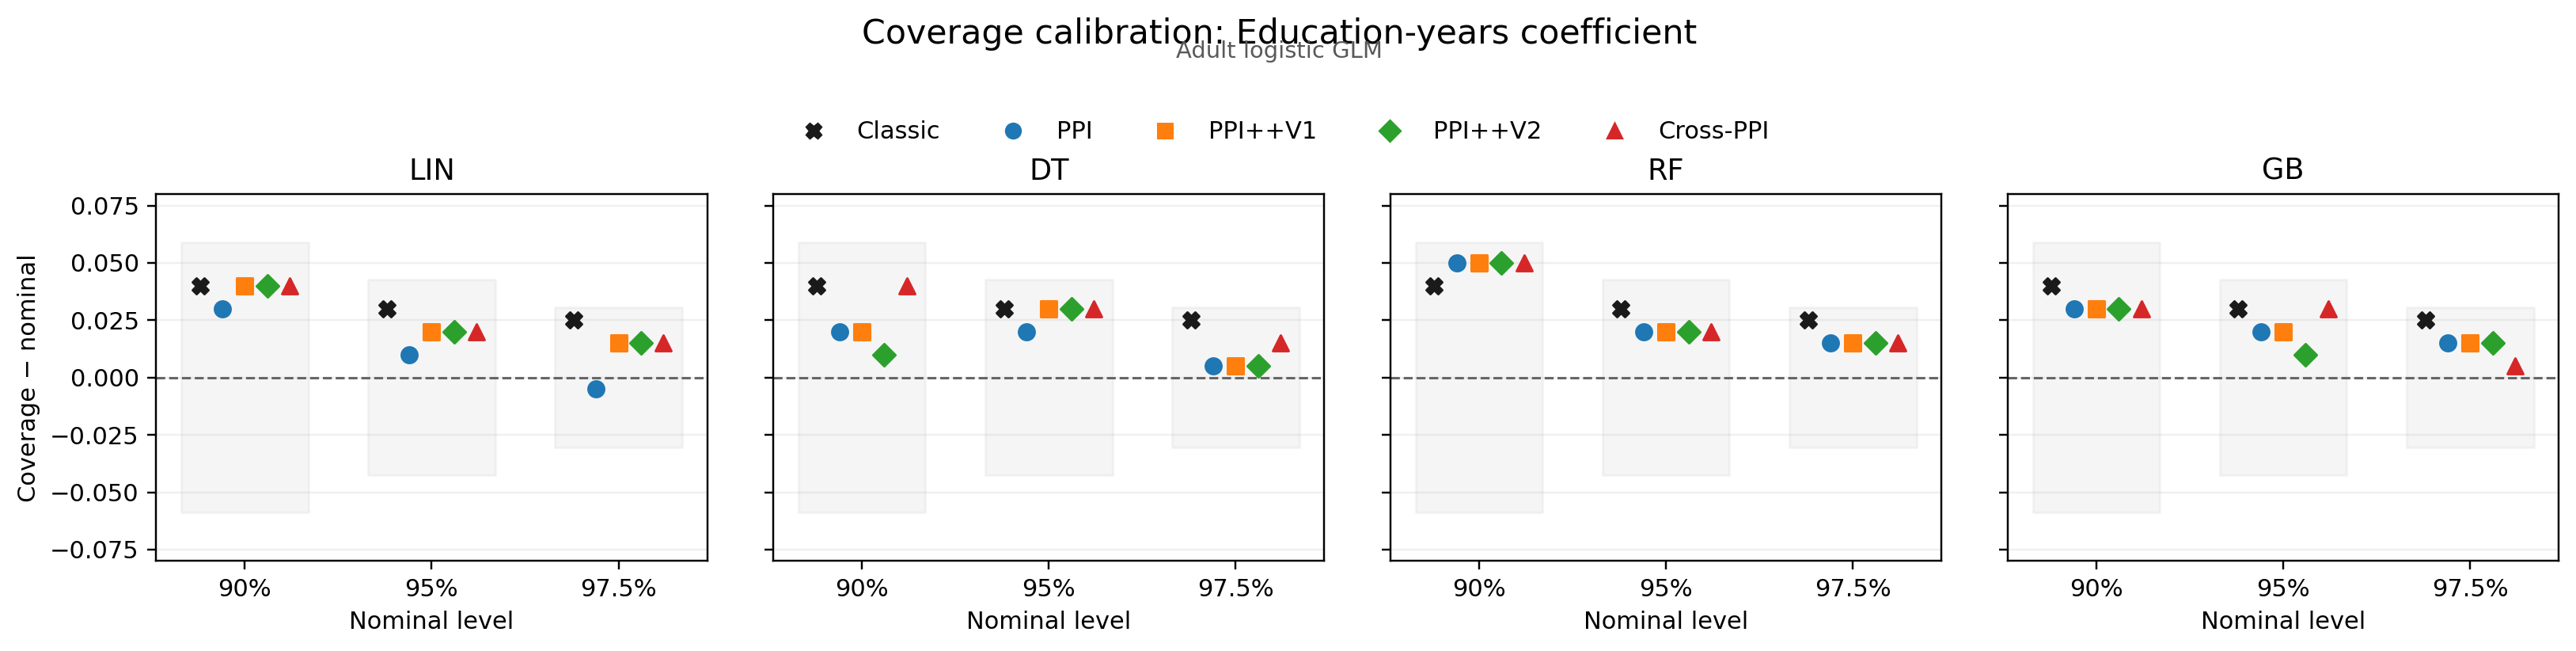

### Adult logistic GLM — hours-per-week

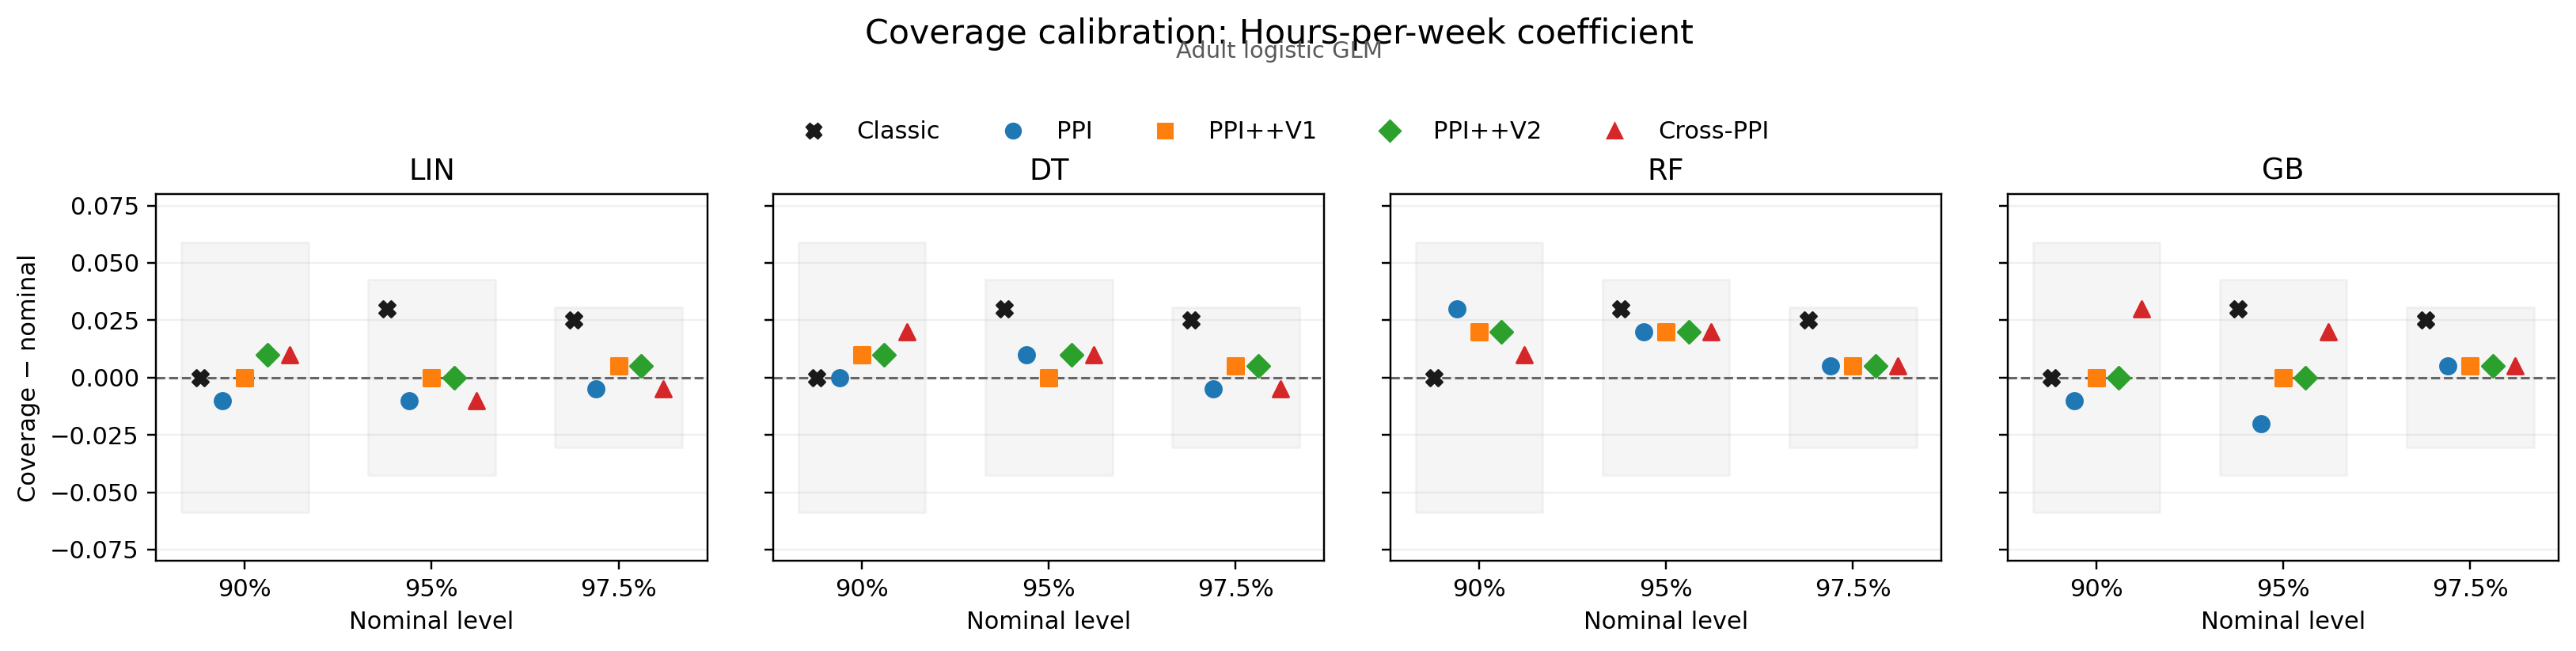

In [6]:
import re
safe=lambda x: re.sub(r"[^A-Za-z0-9_]+","_",x).strip("_")
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base:
        pars=DATASET_CONFIG[exp].get("display_parameters",DATASET_CONFIG[exp]["parameters"])
        for p in pars: display(Markdown(f"### {EXPERIMENT_LABELS[exp]} — {p}")); show_image(base/"figure"/f"diagnostic_coverage_calibration_{safe(p)}.png")


## 8. PPI++V2 tuning effect
For LR and GLM, PPI++V2 selects one shared lambda for the full coefficient vector by minimizing the covariance trace.


In [7]:
cols=["learner_label","parameter","lambda_median","lambda_q25","lambda_q75","v2_to_ppi_width_ratio_median","ppi_coverage_95","v2_coverage_95","coverage_difference"]
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base:
        x=pd.read_csv(base/"table"/"ppiv2_tuning_summary.csv"); display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); display(x[cols])


### Galaxy Zoo 2 mean estimation

,learner_label,parameter,lambda_median,lambda_q25,lambda_q75,v2_to_ppi_width_ratio_median,ppi_coverage_95,v2_coverage_95,coverage_difference
0,DT,smooth_proportion,0.825,0.825,0.850,0.993002,0.99,0.99,0.00
1,GB,smooth_proportion,0.900,0.900,0.925,0.998050,0.99,0.98,-0.01
2,LIN,smooth_proportion,0.925,0.900,0.925,0.998497,0.99,0.99,0.00
3,RF,smooth_proportion,0.925,0.925,0.950,0.998992,0.99,0.99,0.00


### ACS PUMS linear regression

,learner_label,parameter,lambda_median,lambda_q25,lambda_q75,v2_to_ppi_width_ratio_median,ppi_coverage_95,v2_coverage_95,coverage_difference
0,DT,AGEP,0.8000,0.775,0.825,0.992065,1.00,0.99,-0.01
1,DT,SEX_MALE,0.8000,0.775,0.825,0.991119,0.97,0.98,0.01
2,GB,AGEP,0.8750,0.850,0.900,0.995994,0.99,1.00,0.01
3,GB,SEX_MALE,0.8750,0.850,0.900,0.996121,0.97,0.97,0.00
4,LIN,AGEP,0.7750,0.750,0.800,0.987019,0.98,0.98,0.00
5,LIN,SEX_MALE,0.7750,0.750,0.800,1.001542,0.98,0.97,-0.01
6,RF,AGEP,0.9125,0.900,0.925,0.998224,0.99,0.99,0.00
7,RF,SEX_MALE,0.9125,0.900,0.925,0.998968,0.97,0.98,0.01


### Adult logistic GLM

,learner_label,parameter,lambda_median,lambda_q25,lambda_q75,v2_to_ppi_width_ratio_median,ppi_coverage_95,v2_coverage_95,coverage_difference
0,DT,age,0.5500,0.47500,0.625,0.965500,0.96,0.97,0.01
1,DT,education-num,0.5500,0.47500,0.625,0.937903,0.97,0.98,0.01
2,DT,hours-per-week,0.5500,0.47500,0.625,0.966245,0.96,0.96,0.00
3,GB,age,0.7625,0.70000,0.825,0.984951,0.98,0.98,0.00
4,GB,education-num,0.7625,0.70000,0.825,0.981402,0.97,0.96,-0.01
5,GB,hours-per-week,0.7625,0.70000,0.825,0.985847,0.93,0.95,0.02
6,LIN,age,0.8750,0.75000,0.950,0.996911,0.98,0.98,0.00
7,LIN,education-num,0.8750,0.75000,0.950,0.997263,0.96,0.97,0.01
8,LIN,hours-per-week,0.8750,0.75000,0.950,0.999744,0.94,0.95,0.01
9,RF,age,0.7250,0.64375,0.825,0.998897,0.97,0.97,0.00


## 9. Naive ML diagnostic table
Naive ML is an uncorrected prediction-only baseline. It is retained as a validity diagnostic and excluded from relative-width comparisons.


In [8]:
cols=["parameter","learner_label","coverage","coverage_error","avg_width"]
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base:
        x=pd.read_csv(base/"table"/"summary_by_confidence.csv"); x=x[(x.method=="naive_ml") & (x.confidence_level.round(3)==.95)]; display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); display(x[cols])


### Galaxy Zoo 2 mean estimation

,parameter,learner_label,coverage,coverage_error,avg_width
4,smooth_proportion,DT,0.17,-0.78,0.002083
19,smooth_proportion,GB,0.21,-0.74,0.002008
34,smooth_proportion,LIN,0.16,-0.79,0.001992
52,smooth_proportion,RF,0.20,-0.75,0.001952


### ACS PUMS linear regression

,parameter,learner_label,coverage,coverage_error,avg_width
4,AGEP,DT,0.09,-0.86,14.680201
19,AGEP,GB,0.15,-0.80,14.790592
34,AGEP,LIN,0.20,-0.75,14.813543
52,AGEP,RF,0.07,-0.88,13.982528
67,SEX_MALE,DT,0.03,-0.92,708.954000
82,SEX_MALE,GB,0.10,-0.85,708.560704
97,SEX_MALE,LIN,0.17,-0.78,621.266360
115,SEX_MALE,RF,0.00,-0.95,664.046865
130,intercept,DT,0.00,-0.95,807.249231
145,intercept,GB,0.09,-0.86,785.184422


### Adult logistic GLM

,parameter,learner_label,coverage,coverage_error,avg_width
4,age,DT,0.07,-0.88,0.002085
19,age,GB,0.15,-0.80,0.002343
34,age,LIN,0.18,-0.77,0.001937
52,age,RF,0.08,-0.87,0.001645
67,education-num,DT,0.03,-0.92,0.012740
82,education-num,GB,0.12,-0.83,0.013312
97,education-num,LIN,0.10,-0.85,0.011149
115,education-num,RF,0.02,-0.93,0.009406
130,hours-per-week,DT,0.04,-0.91,0.002488
145,hours-per-week,GB,0.20,-0.75,0.002929


## 10. Hyperparameter selection


In [9]:
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base:
        display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); display(pd.read_csv(base/"table"/"learner_training_summary.csv"))
        d=pd.read_csv(base/"other"/"diagnostics.csv"); display(d[d.diagnostic=="fold_tuning"].groupby(["learner","fold_id"],as_index=False).value.agg(["count","mean"]))


### Galaxy Zoo 2 mean estimation

,experiment,learner,learner_label,learner_model,tuned_params,selection_count,selection_rate,validation_score_mean,validation_score_sd,quality_metric,quality_mean,quality_sd,n_train,n_inference
0,a_mean,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 4, ""model__min_samples_le...",10,0.10,0.120768,0.003955,Brier,0.124318,0.001112,4794,19176
1,a_mean,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 4, ""model__min_samples_le...",12,0.12,0.123158,0.004791,Brier,0.125026,0.002025,4794,19176
2,a_mean,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 8, ""model__min_samples_le...",2,0.02,0.124314,0.001396,Brier,0.130700,0.000156,4794,19176
3,a_mean,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 8, ""model__min_samples_le...",76,0.76,0.123606,0.004253,Brier,0.123216,0.001589,4794,19176
4,a_mean,gb,GB,Histogram Gradient Boosting Classifier,"{""model__learning_rate"": 0.1, ""model__max_iter...",1,0.01,0.122038,NaN,Brier,0.119991,NaN,4794,19176
5,a_mean,gb,GB,Histogram Gradient Boosting Classifier,"{""model__learning_rate"": 0.1, ""model__max_iter...",99,0.99,0.118414,0.004467,Brier,0.117759,0.001248,4794,19176
6,a_mean,lin,LIN,Logistic Regression,"{""model__C"": 1.0}",16,0.16,0.122611,0.003054,Brier,0.117840,0.000968,4794,19176
7,a_mean,lin,LIN,Logistic Regression,"{""model__C"": 10.0}",84,0.84,0.116289,0.003731,Brier,0.117374,0.001152,4794,19176
8,a_mean,rf,RF,Random Forest Classifier,"{""model__max_depth"": 12, ""model__min_samples_l...",50,0.50,0.118605,0.004341,Brier,0.118629,0.001368,4794,19176
9,a_mean,rf,RF,Random Forest Classifier,"{""model__max_depth"": 8, ""model__min_samples_le...",50,0.50,0.118800,0.003743,Brier,0.118172,0.001133,4794,19176


,learner,fold_id,count,mean
0,dt,0.0,100,0.120049
1,dt,1.0,100,0.119685
2,dt,2.0,100,0.119435
3,dt,3.0,100,0.119663
4,dt,4.0,100,0.119384
5,gb,0.0,100,0.115244
6,gb,1.0,100,0.114947
7,gb,2.0,100,0.114698
8,gb,3.0,100,0.114857
9,gb,4.0,100,0.114853


### ACS PUMS linear regression

,experiment,learner,learner_label,learner_model,tuned_params,selection_count,selection_rate,validation_score_mean,validation_score_sd,quality_metric,quality_mean,quality_sd,n_train,n_inference
0,b_lr,dt,DT,Decision Tree Regressor,"{""model__max_depth"": 4, ""model__min_samples_le...",2,0.02,4.220647e+09,6.243448e+08,MSE,4.806654e+09,2.308942e+07,6364,25458
1,b_lr,dt,DT,Decision Tree Regressor,"{""model__max_depth"": 4, ""model__min_samples_le...",1,0.01,5.235320e+09,NaN,MSE,4.657039e+09,NaN,6364,25458
2,b_lr,dt,DT,Decision Tree Regressor,"{""model__max_depth"": 8, ""model__min_samples_le...",15,0.15,4.466499e+09,6.571704e+08,MSE,4.469184e+09,1.222908e+08,6364,25458
3,b_lr,dt,DT,Decision Tree Regressor,"{""model__max_depth"": 8, ""model__min_samples_le...",82,0.82,4.421900e+09,6.672546e+08,MSE,4.404955e+09,1.784675e+08,6364,25458
4,b_lr,gb,GB,Histogram Gradient Boosting Regressor,"{""model__learning_rate"": 0.1, ""model__max_iter...",14,0.14,4.259621e+09,7.088043e+08,MSE,4.157366e+09,1.671653e+08,6364,25458
5,b_lr,gb,GB,Histogram Gradient Boosting Regressor,"{""model__learning_rate"": 0.1, ""model__max_iter...",86,0.86,4.093108e+09,6.258977e+08,MSE,4.067113e+09,1.694249e+08,6364,25458
6,b_lr,lin,LIN,Ridge Regression,"{""model__alpha"": 1.0}",1,0.01,4.802435e+09,NaN,MSE,4.396676e+09,NaN,6364,25458
7,b_lr,lin,LIN,Ridge Regression,"{""model__alpha"": 10.0}",99,0.99,4.478328e+09,6.686424e+08,MSE,4.465599e+09,1.799047e+08,6364,25458
8,b_lr,rf,RF,Random Forest Regressor,"{""model__max_depth"": 12, ""model__min_samples_l...",53,0.53,4.189634e+09,6.290304e+08,MSE,4.132331e+09,1.782644e+08,6364,25458
9,b_lr,rf,RF,Random Forest Regressor,"{""model__max_depth"": 8, ""model__min_samples_le...",47,0.47,4.115439e+09,6.731313e+08,MSE,4.115571e+09,1.559756e+08,6364,25458


,learner,fold_id,count,mean
0,dt,0.0,100,4.223766e+09
1,dt,1.0,100,4.282732e+09
2,dt,2.0,100,4.197283e+09
3,dt,3.0,100,4.256889e+09
4,dt,4.0,100,4.231650e+09
5,gb,0.0,100,3.958501e+09
6,gb,1.0,100,4.017392e+09
7,gb,2.0,100,3.939247e+09
8,gb,3.0,100,3.983649e+09
9,gb,4.0,100,3.958368e+09


### Adult logistic GLM

,experiment,learner,learner_label,learner_model,tuned_params,selection_count,selection_rate,validation_score_mean,validation_score_sd,quality_metric,quality_mean,quality_sd,n_train,n_inference
0,c_glm,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 4, ""model__min_samples_le...",60,0.60,0.118117,0.009302,Brier,0.117922,0.003888,990,3963
1,c_glm,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 4, ""model__min_samples_le...",5,0.05,0.127890,0.011232,Brier,0.133204,0.002946,990,3963
2,c_glm,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 8, ""model__min_samples_le...",33,0.33,0.114347,0.012348,Brier,0.123835,0.005432,990,3963
3,c_glm,dt,DT,Decision Tree Classifier,"{""model__max_depth"": 8, ""model__min_samples_le...",2,0.02,0.132397,0.008666,Brier,0.133022,0.008694,990,3963
4,c_glm,gb,GB,Histogram Gradient Boosting Classifier,"{""model__learning_rate"": 0.1, ""model__max_iter...",2,0.02,0.101490,0.011214,Brier,0.116391,0.001693,990,3963
5,c_glm,gb,GB,Histogram Gradient Boosting Classifier,"{""model__learning_rate"": 0.1, ""model__max_iter...",98,0.98,0.108390,0.012444,Brier,0.106720,0.003777,990,3963
6,c_glm,lin,LIN,Logistic Regression,"{""model__C"": 0.1}",38,0.38,0.110585,0.008251,Brier,0.107718,0.003243,990,3963
7,c_glm,lin,LIN,Logistic Regression,"{""model__C"": 1.0}",58,0.58,0.102101,0.008552,Brier,0.107310,0.002870,990,3963
8,c_glm,lin,LIN,Logistic Regression,"{""model__C"": 10.0}",4,0.04,0.098326,0.003130,Brier,0.112243,0.004040,990,3963
9,c_glm,rf,RF,Random Forest Classifier,"{""model__max_depth"": 12, ""model__min_samples_l...",3,0.03,0.113131,0.011372,Brier,0.117622,0.002221,990,3963


,learner,fold_id,count,mean
0,dt,0.0,100,0.108346
1,dt,1.0,100,0.108927
2,dt,2.0,100,0.108960
3,dt,3.0,100,0.109413
4,dt,4.0,100,0.108357
5,gb,0.0,100,0.096880
6,gb,1.0,100,0.097401
7,gb,2.0,100,0.097127
8,gb,3.0,100,0.098088
9,gb,4.0,100,0.097125


## 11. Package and boundary audit


In [10]:
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base:
        cfg=json.loads((base/"other"/"config_used.json").read_text()); d=pd.read_csv(base/"other"/"diagnostics.csv"); w=pd.read_csv(base/"other"/"warnings.csv"); r=pd.read_csv(base/"table"/"replicate_results.csv")
        display(pd.DataFrame([{"experiment":exp,"ppi-python":cfg.get("ppi_python_installed"),"V2 lambda=0 max":d.loc[d.diagnostic.str.contains("lambda0",na=False),"value"].max(),"V2 lambda=1 max":d.loc[d.diagnostic.str.contains("lambda1",na=False),"value"].max(),"warning count":len(w),"failed method count":(r.status!="ok").sum()}]))


,experiment,ppi-python,V2 lambda=0 max,V2 lambda=1 max,warning count,failed method count
0,a_mean,0.2.3,0.0,8.326673e-17,0,0


,experiment,ppi-python,V2 lambda=0 max,V2 lambda=1 max,warning count,failed method count
0,b_lr,0.2.3,0.000009,7.197741e-09,0,0


,experiment,ppi-python,V2 lambda=0 max,V2 lambda=1 max,warning count,failed method count
0,c_glm,0.2.3,1.065814e-14,7.105427e-14,0,0


## 12. Raw file availability


In [11]:
for exp in EXPERIMENTS:
    mode,base=locate(exp)
    if base: display(Markdown(f"### {EXPERIMENT_LABELS[exp]}")); display(pd.DataFrame({"file":[str(p.relative_to(base)) for p in sorted(base.rglob("*")) if p.is_file()]}))


### Galaxy Zoo 2 mean estimation

,file
0,figure\diagnostic_coverage_calibration_smooth_...
1,figure\diagnostic_coverage_calibration_smooth_...
2,figure\inference_performance_95.pdf
3,figure\inference_performance_95.png
4,figure\learner_quality.pdf
5,figure\learner_quality.png
6,other\config_used.json
7,other\diagnostics.csv
8,other\run_log.txt
9,other\warnings.csv


### ACS PUMS linear regression

,file
0,figure\diagnostic_coverage_calibration_AGEP.pdf
1,figure\diagnostic_coverage_calibration_AGEP.png
2,figure\diagnostic_coverage_calibration_SEX_MAL...
3,figure\diagnostic_coverage_calibration_SEX_MAL...
4,figure\inference_performance_95.pdf
5,figure\inference_performance_95.png
6,figure\learner_quality.pdf
7,figure\learner_quality.png
8,other\config_used.json
9,other\diagnostics.csv


### Adult logistic GLM

,file
0,figure\diagnostic_coverage_calibration_age.pdf
1,figure\diagnostic_coverage_calibration_age.png
2,figure\diagnostic_coverage_calibration_educati...
3,figure\diagnostic_coverage_calibration_educati...
4,figure\diagnostic_coverage_calibration_hours_p...
5,figure\diagnostic_coverage_calibration_hours_p...
6,figure\inference_performance_95.pdf
7,figure\inference_performance_95.png
8,figure\learner_quality.pdf
9,figure\learner_quality.png
